# Pertemuan 3: Linear Regression & Polynomial Regression
Nama  : ILMA AQSARI  
NIM   : 105841108023  

"""
Penjelasan:

Pada pertemuan ini mempelajari algoritma Linear Regression dan Polynomial Regression.

Tahapan yang dilakukan:
1. Membuat contoh Simple Linear Regression
2. Melatih model Multiple Linear Regression menggunakan dataset California Housing
3. Membuat model Polynomial Regression
4. Membandingkan performa model
5. Menghitung metrik evaluasi seperti MAE, RMSE dan R2

Tujuan latihan ini adalah memahami cara kerja model regresi
dan bagaimana mengevaluasi hasil prediksi.
"""

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing

============================================================
## Contoh 1 Simple Linear Regression
============================================================

In [6]:
print("=== Contoh 1 Simple Linear Regression ===")

np.random.seed(42)

X = np.random.rand(100,1)*10
y = 3*X[:,0] + 2 + np.random.randn(100)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Koefisien :",model.coef_[0])
print("Intercept :",model.intercept_)
print("R2  :",round(r2_score(y_test,y_pred),3))
print("RMSE:",round(np.sqrt(mean_squared_error(y_test,y_pred)),3))

=== Contoh 1 Simple Linear Regression ===
Koefisien : 2.9598647314960553
Intercept : 2.142913319458568
R2  : 0.992
RMSE: 0.809


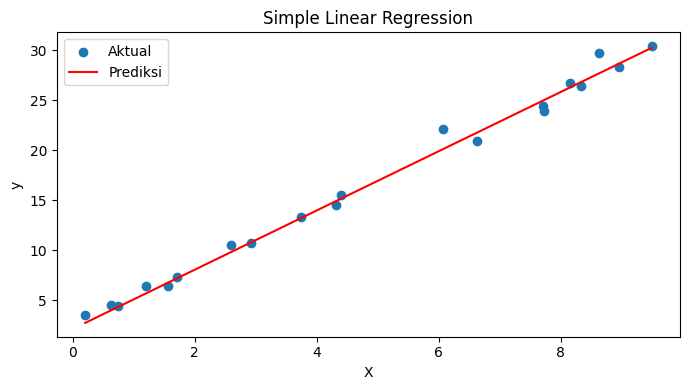

Grafik disimpan ke pertemuan03_simple_lr.png


<Figure size 640x480 with 0 Axes>

In [7]:
# Visualisasi Simple Linear Regression

plt.figure(figsize=(7,4))
plt.scatter(X_test,y_test,label="Aktual")

x_sorted = np.sort(X_test[:,0])
y_line = model.predict(x_sorted.reshape(-1,1))

plt.plot(x_sorted,y_line,color="red",label="Prediksi")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Simple Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

plt.savefig("pertemuan03_simple_lr.png")
print("Grafik disimpan ke pertemuan03_simple_lr.png")

============================================================
## Contoh 2 Multiple Linear Regression
============================================================

In [8]:
print("\n=== Contoh 2 Multiple Linear Regression ===")

data = fetch_california_housing(as_frame=True)
df = data.frame

print("Ukuran Dataset:",df.shape)
print("\n5 Data Pertama")
print(df.head())

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train,y_train)

print("\nR2 test:",round(model_multi.score(X_test,y_test),3))


=== Contoh 2 Multiple Linear Regression ===
Ukuran Dataset: (20640, 9)

5 Data Pertama
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

R2 test: 0.576


In [9]:
print("\nInfo Dataset:")
print(df.info())

print("\nStatistik Dataset:")
print(df.describe())


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Statistik Dataset:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000 

============================================================
## Contoh 3 Polynomial Regression
============================================================

In [10]:
print("\n=== Contoh 3 Polynomial Regression ===")

poly = PolynomialFeatures(degree=2,include_bias=False)

X_train_poly = poly.fit_transform(X_train[[X.columns[0]]])
X_test_poly = poly.transform(X_test[[X.columns[0]]])

poly_model = LinearRegression()
poly_model.fit(X_train_poly,y_train)

print("R2 poly:",round(poly_model.score(X_test_poly,y_test),3))


=== Contoh 3 Polynomial Regression ===
R2 poly: 0.463


In [18]:
# Visualisasi Polynomial Regression

plt.figure(figsize=(7,4))

X_test_d1 = X_test[[X.columns[0]]]

X_plot = np.linspace(
 X_test_d1.min(),
 X_test_d1.max(),
 100
).reshape(-1,1)

X_plot_poly = poly.transform(X_plot)

y_plot = poly_model.predict(X_plot_poly)

plt.scatter(X_test_d1,y_test,label="Aktual")
plt.plot(X_plot,y_plot,color="red",label="Polynomial")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression")

plt.legend()

plt.tight_layout()
plt.savefig("pertemuan03_poly.png")
plt.close()

print("Grafik polynomial disimpan ke pertemuan03_poly.png")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Grafik polynomial disimpan ke pertemuan03_poly.png


============================================================
## TUGAS 2 Multiple LR - Metrik Lengkap
============================================================

In [12]:
print("\n=== Tugas 2 Multiple LR ===")

y_pred_multi = model_multi.predict(X_test)

print("MAE :",round(mean_absolute_error(y_test,y_pred_multi),3))
print("RMSE:",round(np.sqrt(mean_squared_error(y_test,y_pred_multi)),3))
print("R2  :",round(r2_score(y_test,y_pred_multi),3))


=== Tugas 2 Multiple LR ===
MAE : 0.533
RMSE: 0.746
R2  : 0.576


============================================================
## TUGAS 3 Bandingkan Degree
============================================================

In [13]:
print("\n=== Tugas 3 Polynomial Comparison ===")

X_train_d1 = X_train[[X.columns[0]]]
X_test_d1 = X_test[[X.columns[0]]]

model_d1 = LinearRegression()
model_d1.fit(X_train_d1,y_train)

print("Degree 1 R2:",round(model_d1.score(X_test_d1,y_test),3))
print("Degree 2 R2:",round(poly_model.score(X_test_poly,y_test),3))
print("Model degree 2 biasanya lebih fleksibel karena dapat mengikuti pola data yang tidak linear")


=== Tugas 3 Polynomial Comparison ===
Degree 1 R2: 0.459
Degree 2 R2: 0.463
Model degree 2 biasanya lebih fleksibel karena dapat mengikuti pola data yang tidak linear


============================================================
## TUGAS 4 Polynomial Metrik Lengkap
============================================================

In [14]:
print("\n=== Tugas 4 Metrik Lengkap ===")

y_pred_poly = poly_model.predict(X_test_poly)

print("MAE :",round(mean_absolute_error(y_test,y_pred_poly),3))
print("RMSE:",round(np.sqrt(mean_squared_error(y_test,y_pred_poly)),3))
print("R2  :",round(r2_score(y_test,y_pred_poly),3))


=== Tugas 4 Metrik Lengkap ===
MAE : 0.628
RMSE: 0.839
R2  : 0.463


In [15]:
print("\nInterpretasi Model:")
print("Jika nilai X naik 1 satuan maka y naik sekitar",
      round(model.coef_[0],2))


Interpretasi Model:
Jika nilai X naik 1 satuan maka y naik sekitar 2.96


In [16]:
print("\nKesimpulan:")
print("1. Linear Regression cocok untuk hubungan linear")
print("2. Polynomial Regression bisa menangkap pola lebih kompleks")
print("3. RMSE kecil menunjukkan prediksi cukup baik")


Kesimpulan:
1. Linear Regression cocok untuk hubungan linear
2. Polynomial Regression bisa menangkap pola lebih kompleks
3. RMSE kecil menunjukkan prediksi cukup baik


In [17]:
print("\n✅ Pertemuan 03 selesai.")


✅ Pertemuan 03 selesai.
